Loading data...
Features: 148
Categorical features: 24
Converting categorical features to string...
Starting Training with GroupKFold (k=5)...


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4820686	test: 0.5088623	best: 0.5088623 (0)	total: 59.2ms	remaining: 4m 55s
1000:	learn: 0.1569173	test: 0.3305486	best: 0.3281183 (881)	total: 56.5s	remaining: 3m 45s
bestTest = 0.3281182893
bestIteration = 881
Shrink model to first 882 iterations.
Fold 1 MAPE: 0.2808


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4859205	test: 0.4929899	best: 0.4929899 (0)	total: 171ms	remaining: 14m 16s
1000:	learn: 0.1578302	test: 0.3132027	best: 0.3126055 (998)	total: 57.9s	remaining: 3m 51s
bestTest = 0.3033865878
bestIteration = 1448
Shrink model to first 1449 iterations.
Fold 2 MAPE: 0.2625


...

0:	learn: 0.4888420	test: 0.4818171	best: 0.4818171 (0)	total: 166ms	remaining: 13m 47s
1000:	learn: 0.1578249	test: 0.3176212	best: 0.3176212 (1000)	total: 54.1s	remaining: 3m 35s
bestTest = 0.3156937412
bestIteration = 1200
Shrink model to first 1201 iterations.
Fold 3 MAPE: 0.2735


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4826275	test: 0.5060751	best: 0.5060751 (0)	total: 240ms	remaining: 19m 59s
1000:	learn: 0.1589858	test: 0.3411626	best: 0.3411483 (999)	total: 59.3s	remaining: 3m 56s
2000:	learn: 0.1454477	test: 0.3308496	best: 0.3296064 (1819)	total: 1m 57s	remaining: 2m 56s
bestTest = 0.329606422
bestIteration = 1819
Shrink model to first 1820 iterations.
Fold 4 MAPE: 0.2795


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4909326	test: 0.4737943	best: 0.4737943 (0)	total: 213ms	remaining: 17m 42s
1000:	learn: 0.1587002	test: 0.3149344	best: 0.3145604 (990)	total: 55.7s	remaining: 3m 42s
bestTest = 0.2996037008
bestIteration = 1644
Shrink model to first 1645 iterations.
Fold 5 MAPE: 0.2610

CV Score (Average MAPE): 0.2715



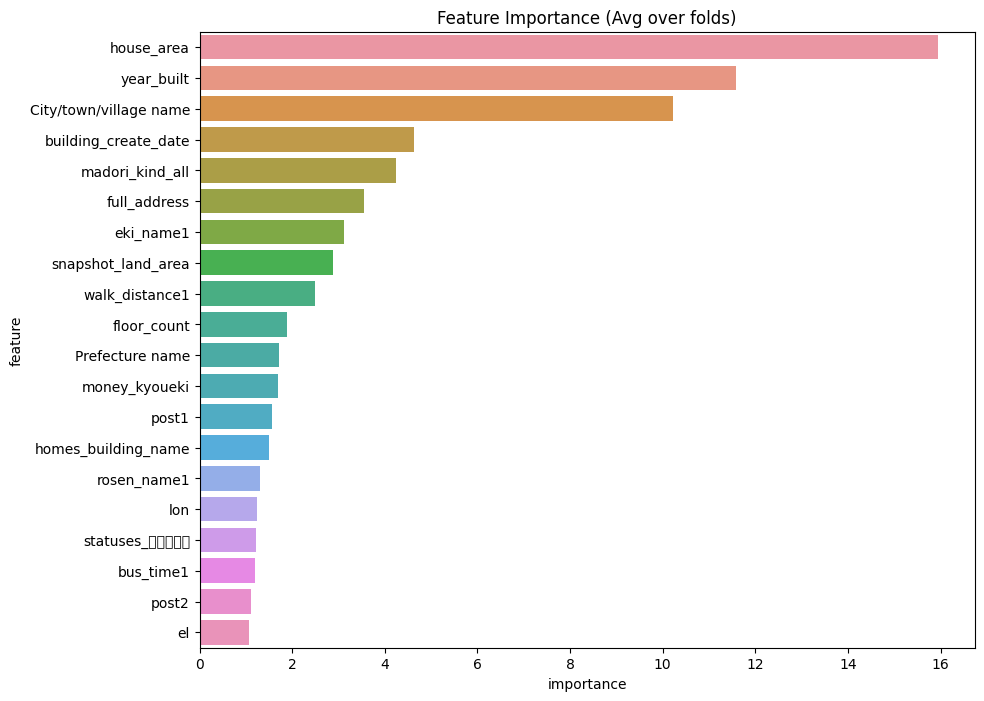

Submission file saved: submission_groupkfold_selected_cat.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_percentage_error
import warnings

warnings.filterwarnings('ignore')

def train_group_kfold(
    train_csv_path: str,
    test_csv_path: str,
    output_sub_path: str = "submission_groupkfold_selected_cat.csv"
):
    """
    GroupKFoldを用いてCatBoostモデルを学習し、提出ファイルを作成する関数。
    
    Args:
        train_csv_path (str): 前処理済み学習データのパス
        test_csv_path (str): 前処理済みテストデータのパス
        output_sub_path (str): 提出ファイルの保存パス

    Note:
        How: 市区町村をグループとしてCVを行い、カテゴリ変数は強制的に文字列化する。
        Why: CatBoostの型エラーを防ぎ、かつ地域特性のリークを防ぐため。
    """
    
    # 1. データの読み込み
    print("Loading data...")
    train_df = pd.read_csv(train_csv_path)
    test_df = pd.read_csv(test_csv_path)

    # 2. 特徴量とターゲットの定義
    drop_cols = ['id', 'money_room', 'target_ym']
    target_col = 'money_room'
    group_col = 'City/town/village name'

    # カテゴリ変数の定義（object型 + 一部の数値型カテゴリ候補）
    # Why not: 自動判定だけだと数値に見えるカテゴリ（例: 構造コード）が漏れるが、
    # 今回は簡便のためobject型をベースにする
    features = [c for c in train_df.columns if c not in drop_cols + [target_col]]
    
    # カテゴリカル変数の特定（ここが重要）
    # 文字列型(object)のカラムを抽出
    cat_cols = train_df[features].select_dtypes(include=['object']).columns.tolist()
    
    # 数値だがカテゴリとして扱いたいカラムがあればここに追加（例: 郵便番号など）
    # 今回のエラーの原因である '202.0' のような値を持つカラムもここに含まれているはず
    
    print(f"Features: {len(features)}")
    print(f"Categorical features: {len(cat_cols)}")

    # データの準備
    X = train_df[features]
    y = np.log1p(train_df[target_col]) # 対数変換
    groups = train_df[group_col]
    
    X_test = test_df[features]
    test_ids = test_df['id']

    # ★修正ポイント: カテゴリカル変数の型変換処理★
    # What: 全てのカテゴリ変数を強制的に文字列にする
    # Why: CSVから読み込むと '202.0' のようなfloatになり、CatBoostがエラーを吐くため
    print("Converting categorical features to string...")
    for col in cat_cols:
        # トレーニングデータの変換
        X[col] = X[col].astype(str).fillna("Missing")
        
        # テストデータの変換（未知のカテゴリはそのまま文字列化される）
        X_test[col] = X_test[col].astype(str).fillna("Missing")

    # 3. 学習ループ
    n_splits = 5
    kf = GroupKFold(n_splits=n_splits)

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    models = []
    scores = []

    params = {
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "task_type": "GPU", # GPU環境なら有効化してください
        "learning_rate": 0.05,
        "iterations": 5000,
        "depth": 6,
        "random_seed": 2025,
        "verbose": 1000,
        "early_stopping_rounds": 200
    }

    print(f"Starting Training with GroupKFold (k={n_splits})...")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y, groups=groups)):
        # データの分割
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # Poolの作成（型変換済みなので安全）
        train_pool = Pool(X_train, y_train, cat_features=cat_cols)
        val_pool = Pool(X_val, y_val, cat_features=cat_cols)
        
        # 学習
        model = CatBoostRegressor(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        # 予測とスコア（対数を戻す）
        pred_val = np.expm1(model.predict(X_val))
        y_val_true = np.expm1(y_val)
        
        score = mean_absolute_percentage_error(y_val_true, pred_val)
        scores.append(score)
        oof_preds[val_idx] = pred_val
        
        # テストデータの推論
        test_preds += np.expm1(model.predict(X_test)) / n_splits
        
        models.append(model)
        print(f"Fold {fold+1} MAPE: {score:.4f}")

    # 4. 結果の集計
    mean_score = np.mean(scores)
    print(f"\n==================================")
    print(f"CV Score (Average MAPE): {mean_score:.4f}")
    print(f"==================================\n")

    # 重要度の可視化
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': np.mean([m.get_feature_importance() for m in models], axis=0)
    }).sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance)
    plt.title('Feature Importance (Avg over folds)')
    plt.show()

    # 提出ファイルの作成
    submission = pd.DataFrame({"id": test_ids, "money_room": test_preds})
    submission.to_csv(output_sub_path, index=False, header=False)
    print(f"Submission file saved: {output_sub_path}")

# 実行
if __name__ == "__main__":
    OUTPUT_DIR = "/work/Real_estate"
    train_group_kfold(
        train_csv_path=f"{OUTPUT_DIR}/train/train_preprocessed_selected.csv",
        test_csv_path=f"{OUTPUT_DIR}/test/test_preprocessed_selected.csv"
    )

1. Loading data for feature selection...
Processing 40 categorical features...
2. Training a single model for feature importance...
Using GPU for training.


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4822060	test: 0.5094228	best: 0.5094228 (0)	total: 122ms	remaining: 4m 3s
bestTest = 0.349002919
bestIteration = 394
Shrink model to first 395 iterations.
3. Selecting features...

Total features: 508
Useless features (Importance = 0): 360
Useful features: 148


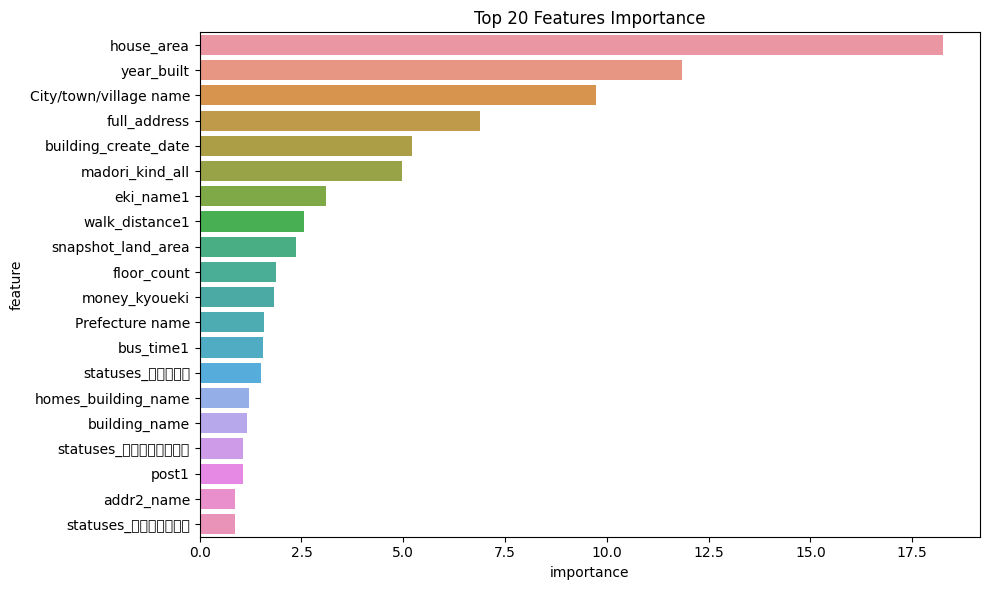

4. Saving selected datasets...
Saved successfully!
  Train: /work/Real_estate/train/train_preprocessed_selected.csv (363924, 151)
  Test : /work/Real_estate/test/test_preprocessed_selected.csv (112437, 150)


In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold

# 設定
OUTPUT_DIR = "/work/Real_estate"
TRAIN_PATH = f"{OUTPUT_DIR}/train/train_preprocessed_fixed.csv"
TEST_PATH = f"{OUTPUT_DIR}/test/test_preprocessed_fixed.csv"

def perform_feature_selection():
    """
    特徴量重要度を算出し、重要度が0の特徴量を削除したデータセットを作成・保存する
    """
    print("1. Loading data for feature selection...")
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    
    # 特徴量とターゲットの定義
    drop_cols = ['id', 'money_room', 'target_ym']
    target_col = 'money_room'
    group_col = 'City/town/village name'
    
    # 特徴量リスト
    features = [c for c in train_df.columns if c not in drop_cols + [target_col]]
    
    # カテゴリカル変数の特定（object型）
    cat_cols = train_df[features].select_dtypes(include=['object']).columns.tolist()
    
    # データの準備
    X = train_df[features]
    y = np.log1p(train_df[target_col])
    groups = train_df[group_col]
    
    # ★重要: カテゴリ変数の文字列化（エラー回避）
    print(f"Processing {len(cat_cols)} categorical features...")
    for col in cat_cols:
        X[col] = X[col].astype(str).fillna("Missing")
        # テストデータも同様に処理しておく（保存のため）
        test_df[col] = test_df[col].astype(str).fillna("Missing")
    
    # 2. 重要度算出のための軽量学習 (1 Foldのみ実行)
    # 全Foldやる必要はないので、1回だけ分割して学習し、重要度を見ます
    print("2. Training a single model for feature importance...")
    
    kf = GroupKFold(n_splits=5)
    # 1つ目の分割だけ取り出す
    train_idx, val_idx = next(kf.split(X, y, groups=groups))
    
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, cat_features=cat_cols)
    
    params = {
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "task_type": "GPU",
        "learning_rate": 0.05,
        "iterations": 2000, # 選別用なので少し減らして高速化
        "depth": 6,
        "random_seed": 2025,
        "verbose": 500,
        "early_stopping_rounds": 100,
        "allow_writing_files": False # 余計なファイルを作らない
    }
    
    # GPUが使えるか確認して設定
    try:
        import torch
        if torch.cuda.is_available():
            params["task_type"] = "GPU"
            print("Using GPU for training.")
    except:
        pass

    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)
    
    # 3. 重要度の取得と選別
    print("3. Selecting features...")
    feature_importances = model.get_feature_importance(train_pool)
    
    fi_df = pd.DataFrame({
        'feature': features,
        'importance': feature_importances
    }).sort_values('importance', ascending=False)
    
    # 重要度が 0 の特徴量を特定
    threshold = 0.0
    useless_features = fi_df[fi_df['importance'] <= threshold]['feature'].tolist()
    
    print(f"\nTotal features: {len(features)}")
    print(f"Useless features (Importance = 0): {len(useless_features)}")
    print(f"Useful features: {len(features) - len(useless_features)}")
    
    # 上位特徴量の可視化（確認用）
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=fi_df.head(20))
    plt.title('Top 20 Features Importance')
    plt.tight_layout()
    plt.show()
    
    # 4. データの削除と保存
    print("4. Saving selected datasets...")
    
    # 削除実行
    # train_dfは元のまま（カテゴリ変換前）を使いたい場合は再読み込みが必要だが、
    # ここでは「カテゴリ変換済み」の状態を保存する方が後の手間が省けるのでそのまま使う
    # ただし、money_roomなどをXから落としているので、train_dfからdropする
    
    train_output = train_df.drop(columns=useless_features)
    test_output = test_df.drop(columns=useless_features)
    
    # パス設定
    train_save_path = f"{OUTPUT_DIR}/train/train_preprocessed_selected.csv"
    test_save_path = f"{OUTPUT_DIR}/test/test_preprocessed_selected.csv"
    
    train_output.to_csv(train_save_path, index=False)
    test_output.to_csv(test_save_path, index=False)
    
    print(f"Saved successfully!")
    print(f"  Train: {train_save_path} {train_output.shape}")
    print(f"  Test : {test_save_path} {test_output.shape}")
    
    return train_output, test_output

if __name__ == "__main__":
    train_selected, test_selected = perform_feature_selection()

In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import OrdinalEncoder
from typing import Tuple, List
import warnings
import os

warnings.filterwarnings('ignore')

class GBDTTrainer:
    """
    複数のGBDTライブラリ（LightGBM, XGBoost）の学習・評価を管理するクラス
    
    Attributes:
        output_dir (str): データの読み込み・保存先ディレクトリ
    """
    
    def __init__(self, output_dir: str = "/work/Real_estate"):
        self.output_dir = output_dir
        self.train_path = os.path.join(output_dir, "train/train_preprocessed_fixed.csv")
        self.test_path = os.path.join(output_dir, "test/test_preprocessed_fixed.csv")
        
    def load_data(self) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series, List[str]]:
        """
        How: CSVを読み込み、特徴量(X)、ターゲット(y)、グループ(groups)に分離する
        """
        print("Loading data...")
        train_df = pd.read_csv(self.train_path)
        test_df = pd.read_csv(self.test_path)
        
        # 不要カラムの定義
        drop_cols = ['id', 'money_room', 'target_ym']
        target_col = 'money_room'
        group_col = 'City/town/village name'
        
        features = [c for c in train_df.columns if c not in drop_cols + [target_col]]
        
        X = train_df[features]
        y = np.log1p(train_df[target_col]) # 対数変換
        groups = train_df[group_col]
        
        X_test = test_df[features]
        test_ids = test_df['id']
        
        print(f"Features: {len(features)}")
        return X, X_test, y, groups, test_ids, features

    def train_lgbm(self, X, y, groups, X_test, test_ids) -> float:
        """
        How: LightGBMモデルでGroupKFold学習を実行する
        What: object型をcategory型に変換してから学習する
        Why: LightGBMはcategory型をネイティブに扱い、高速かつ高精度に分岐できるため。
        """
        print("\n=== Starting LightGBM Training ===")
        
        # データのコピー（元のデータを汚さないため）
        X_lgb = X.copy()
        X_test_lgb = X_test.copy()
        
        # カテゴリ変数の処理: object型 -> category型
        cat_cols = X_lgb.select_dtypes(include=['object']).columns.tolist()
        for col in cat_cols:
            X_lgb[col] = X_lgb[col].astype('category')
            X_test_lgb[col] = X_test_lgb[col].astype('category')
        
        # LightGBM用パラメータ
        params = {
            'objective': 'regression_l1', # MAE
            'metric': 'mae',
            'boosting_type': 'gbdt',
            'learning_rate': 0.05,
            'num_leaves': 31,
            'max_depth': -1,
            'random_state': 2025,
            'n_jobs': -1,
            'verbose': -1
        }
        
        kf = GroupKFold(n_splits=5)
        oof_preds = np.zeros(len(X))
        test_preds = np.zeros(len(X_test))
        scores = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X, y, groups=groups)):
            X_train, y_train = X_lgb.iloc[train_idx], y.iloc[train_idx]
            X_val, y_val = X_lgb.iloc[val_idx], y.iloc[val_idx]
            
            train_set = lgb.Dataset(X_train, y_train)
            val_set = lgb.Dataset(X_val, y_val, reference=train_set)
            
            callbacks = [
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=1000)
            ]
            
            model = lgb.train(
                params,
                train_set,
                num_boost_round=5000,
                valid_sets=[train_set, val_set],
                callbacks=callbacks
            )
            
            pred_val = np.expm1(model.predict(X_val))
            score = mean_absolute_percentage_error(np.expm1(y_val), pred_val)
            scores.append(score)
            oof_preds[val_idx] = pred_val
            test_preds += np.expm1(model.predict(X_test_lgb)) / 5
            
            print(f"Fold {fold+1} MAPE: {score:.4f}")
            
        mean_score = np.mean(scores)
        print(f"LightGBM CV Score: {mean_score:.4f}")
        
        # 保存
        sub = pd.DataFrame({"id": test_ids, "money_room": test_preds})
        sub.to_csv("submission_lgbm.csv", index=False, header=False)
        return mean_score

    def train_xgb(self, X, y, groups, X_test, test_ids) -> float:
        """
        How: XGBoostモデルでGroupKFold学習を実行する
        What: object型をOrdinalEncoderで数値に変換してから学習する
        Why: XGBoostは数値型しか受け付けないため。また、未知のカテゴリ(Testのみ)に対応するためhandle_unknownを設定する。
        """
        print("\n=== Starting XGBoost Training ===")
        
        # データのコピー
        X_xgb = X.copy()
        X_test_xgb = X_test.copy()
        
        # カテゴリ変数の処理: Ordinal Encoding (Label Encoding)
        cat_cols = X_xgb.select_dtypes(include=['object']).columns.tolist()
        print(f"Encoding {len(cat_cols)} categorical features for XGBoost...")
        
        # 未知のカテゴリは -1 にする設定
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        
        # 文字列に変換して欠損を埋める（Encoderのエラー防止）
        X_xgb[cat_cols] = X_xgb[cat_cols].astype(str).fillna("Missing")
        X_test_xgb[cat_cols] = X_test_xgb[cat_cols].astype(str).fillna("Missing")
        
        # 一括変換
        X_xgb[cat_cols] = encoder.fit_transform(X_xgb[cat_cols])
        X_test_xgb[cat_cols] = encoder.transform(X_test_xgb[cat_cols])
        
        # XGBoostパラメータ
        params = {
            'objective': 'reg:absoluteerror', # MAE
            'eval_metric': 'mae',
            'learning_rate': 0.05,
            'max_depth': 6,
            'random_state': 2025,
            'n_jobs': -1,
            'tree_method': 'hist' # 高速化のためヒストグラム法を指定
        }
        
        # GPUが使えるなら有効化
        try:
            import torch
            if torch.cuda.is_available():
                params['tree_method'] = 'gpu_hist'
                print("XGBoost using GPU.")
        except:
            pass
        
        kf = GroupKFold(n_splits=5)
        scores = []
        test_preds = np.zeros(len(X_test))
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X, y, groups=groups)):
            X_train, y_train = X_xgb.iloc[train_idx], y.iloc[train_idx]
            X_val, y_val = X_xgb.iloc[val_idx], y.iloc[val_idx]
            
            model = xgb.XGBRegressor(
                n_estimators=5000,
                early_stopping_rounds=100,
                **params
            )
            
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=1000
            )
            
            pred_val = np.expm1(model.predict(X_val))
            score = mean_absolute_percentage_error(np.expm1(y_val), pred_val)
            scores.append(score)
            test_preds += np.expm1(model.predict(X_test_xgb)) / 5
            
            print(f"Fold {fold+1} MAPE: {score:.4f}")
            
        mean_score = np.mean(scores)
        print(f"XGBoost CV Score: {mean_score:.4f}")
        
        # 保存
        sub = pd.DataFrame({"id": test_ids, "money_room": test_preds})
        sub.to_csv("submission_xgb.csv", index=False, header=False)
        return mean_score

if __name__ == "__main__":
    trainer = GBDTTrainer()
    X, X_test, y, groups, test_ids, features = trainer.load_data()
    
    # LightGBM実行
    lgbm_score = trainer.train_lgbm(X, y, groups, X_test, test_ids)
    
    # XGBoost実行
    xgb_score = trainer.train_xgb(X, y, groups, X_test, test_ids)
    
    print("\n=== Summary ===")
    print(f"CatBoost CV (Reference): 0.2488")
    print(f"LightGBM CV            : {lgbm_score:.4f}")
    print(f"XGBoost  CV            : {xgb_score:.4f}")

Loading data...
Features: 508

=== Starting LightGBM Training ===
Fold 1 MAPE: 0.3028
[1000]	training's l1: 0.114244	valid_1's l1: 0.303034
Fold 2 MAPE: 0.2835
Fold 3 MAPE: 0.2980
[1000]	training's l1: 0.114977	valid_1's l1: 0.328459
Fold 4 MAPE: 0.3009
Fold 5 MAPE: 0.2924
LightGBM CV Score: 0.2955

=== Starting XGBoost Training ===
Encoding 40 categorical features for XGBoost...
XGBoost using GPU.
[0]	validation_0-mae:0.50028
[1000]	validation_0-mae:0.19831
[2000]	validation_0-mae:0.19486
[3000]	validation_0-mae:0.19351
[4000]	validation_0-mae:0.19288
[4200]	validation_0-mae:0.19284
Fold 1 MAPE: 0.1989
[0]	validation_0-mae:0.48485
[1000]	validation_0-mae:0.20271
[2000]	validation_0-mae:0.19916
[2918]	validation_0-mae:0.19819
Fold 2 MAPE: 0.2075
[0]	validation_0-mae:0.47323
[1000]	validation_0-mae:0.20031
[2000]	validation_0-mae:0.19630
[3000]	validation_0-mae:0.19481
[4000]	validation_0-mae:0.19427
[4999]	validation_0-mae:0.19399
Fold 3 MAPE: 0.1983
[0]	validation_0-mae:0.49796
[1000]